# Reactive Surveillance and Targeted Vaccination

## Motivation

The campaigns in `nb_17` and `nb_18` were *pre-scheduled*: every vaccination round was decided up-front at simulation construction time.  In real outbreak response you usually do not know months in advance when or where to vaccinate — instead, you watch a surveillance system and **react** when the case count somewhere exceeds an alarm threshold.

This notebook builds that reactive loop on top of the `Campaign` component:

1. A `Surveillance` intervention fires on the **first of every month** (using date-valued `when` entries with a `start_date` of 2025-01-01).
2. Each firing inspects new infections over the past 30 days, applies a *sensitivity* (probability of detecting each case), and flags any node whose detected case count exceeds an *alarm threshold*.
3. When an alarm fires, the surveillance intervention **mutates the Campaign in-place** by injecting a new `Vaccination` schedule entry for the next tick.  This requires reaching into the Campaign's `_at_tick` dictionary — a private data structure, but exactly the kind of thing we want to be able to drive from within an intervention.  A future revision of `Campaign` could expose a public `add_intervention(tick, entry)` method.
4. The new vaccination round can target one of two sets, controlled by a `mode` parameter:
   - **`notable_only`** — vaccinate only the alarmed node(s).
   - **`alarm_and_neighbors`** — vaccinate the alarmed node(s) **and** every node connected to them by a non-zero network edge.

## Scenario

An 11-node three-tier metapopulation:

| Tier | Count | Population per node | Notes |
|---|---|---|---|
| Hub | 1 | 1,000,000 | central node; well above critical community size |
| Inner ring | 5 | 100,000 | each connected to hub + two inner-ring neighbours |
| Outer ring | 5 | 10,000 | each connected to two inner-ring neighbours + two outer-ring neighbours |

Disease parameters: SIR with $R_0 = 2.5$, infectious period $D_I = 7$ days, so $\beta = R_0 / D_I \approx 0.357/\text{day}$ and $\gamma = 1/D_I \approx 0.143/\text{day}$.  At endemic equilibrium $S^*/N = 1/R_0 = 0.40$.

Vital dynamics: 60-year average lifespan with `NonDiseaseMortality` + `ConstantPopBirths`.

Importation: 5 cases dropped into the hub every 28 days (4 weeks) to keep transmission alive.

Simulation length: 5 years starting January 1, 2025.

We will run three scenarios — no surveillance, surveillance in `notable_only` mode, surveillance in `alarm_and_neighbors` mode — and compare them.

In [ ]:
from datetime import date, timedelta

import numpy as np
import matplotlib.pyplot as plt

from laser.core import PropertySet
from laser.core.utils import grid
from laser.generic.utils import ValuesMap
from laser.cohorts import Model, Campaign, Intervention, ScheduledEntry
from laser.cohorts.vitaldynamics import NonDiseaseMortality, ConstantPopBirths
import laser.cohorts.SIR as SIR

np.random.seed(42)

## Disease, demographic, and simulation parameters

In [32]:
# Disease parameters
R0                = 2.5
infectious_period = 7.0
gamma_val         = 1.0 / infectious_period           # 0.143/day
beta_val          = R0 / infectious_period            # 0.357/day

# Vital dynamics — 60-year life expectancy
life_expectancy_years = 60.0
r_mortality_val       = 1.0 / (life_expectancy_years * 365.0)

# Simulation length: 5 years starting January 1, 2025
start_date_str = "2025-01-01"
start_date     = date.fromisoformat(start_date_str)
sim_years      = 5
nticks         = sim_years * 365
end_date       = start_date + timedelta(days=nticks)

print(f"R0           = {R0}")
print(f"β            = {beta_val:.4f}/day")
print(f"γ            = {gamma_val:.4f}/day")
print(f"r_mortality  = {r_mortality_val:.3e}/day")
print(f"sim window   = {start_date} → {end_date}  ({nticks} ticks)")
print(f"endemic S/N  = 1/R0 = {1.0/R0:.2f}")

R0           = 2.5
β            = 0.3571/day
γ            = 0.1429/day
r_mortality  = 4.566e-05/day
sim window   = 2025-01-01 → 2029-12-31  (1825 ticks)
endemic S/N  = 1/R0 = 0.40


## Network — three-tier hub-and-spoke

Nodes 0..10 are arranged as: hub (0), inner ring (1..5), outer ring (6..10).  Outer ring node `k` sits *between* inner ring nodes `k` and `k+1` (modulo 5), giving every outer node two inner-ring neighbours.

Four coupling strengths are used, all symmetric:

| Edge type | Weight | Purpose |
|---|---|---|
| Hub ↔ inner | 0.06 | Dominant inflow/outflow for inner ring |
| Inner ↔ inner (ring neighbours) | 0.025 | Lateral spread along inner ring |
| Outer ↔ inner (two closest) | 0.015 | Each outer node draws from two inner ring sources |
| Outer ↔ outer (ring neighbours) | 0.010 | Lateral spread along outer ring |

In [18]:
n_inner = 5
n_outer = 5
n_nodes = 1 + n_inner + n_outer

hub_idx   = 0
inner_idx = list(range(1, 1 + n_inner))
outer_idx = list(range(1 + n_inner, 1 + n_inner + n_outer))

populations = np.array(
    [1_000_000] + [100_000] * n_inner + [10_000] * n_outer,
    dtype=np.int64,
)

# Coupling strengths
w_hub_inner   = 0.06
w_inner_inner = 0.025
w_inner_outer = 0.015
w_outer_outer = 0.010

network = np.zeros((n_nodes, n_nodes), dtype=np.float32)

# Hub <-> inner ring
for i in inner_idx:
    network[hub_idx, i] = w_hub_inner
    network[i, hub_idx] = w_hub_inner

# Inner ring neighbours
for k in range(n_inner):
    a, b = inner_idx[k], inner_idx[(k + 1) % n_inner]
    network[a, b] = w_inner_inner
    network[b, a] = w_inner_inner

# Outer ring neighbours
for k in range(n_outer):
    a, b = outer_idx[k], outer_idx[(k + 1) % n_outer]
    network[a, b] = w_outer_outer
    network[b, a] = w_outer_outer

# Outer ring <-> two closest inner ring nodes
for k in range(n_outer):
    o  = outer_idx[k]
    ia = inner_idx[k]
    ib = inner_idx[(k + 1) % n_inner]
    network[o, ia] = w_inner_outer
    network[ia, o] = w_inner_outer
    network[o, ib] = w_inner_outer
    network[ib, o] = w_inner_outer

print(f"network shape: {network.shape}")
print(f"edge count    : {int((network > 0).sum() // 2)}")
print(f"sum of weights: {network.sum():.3f}")

network shape: (11, 11)
edge count    : 25
sum of weights: 1.250


### Network visualisation

Hub at the centre, inner ring at radius 1, outer ring at radius 2 offset by half a ring spacing so each outer node sits between two inner nodes.  Edge thickness scales with coupling weight.

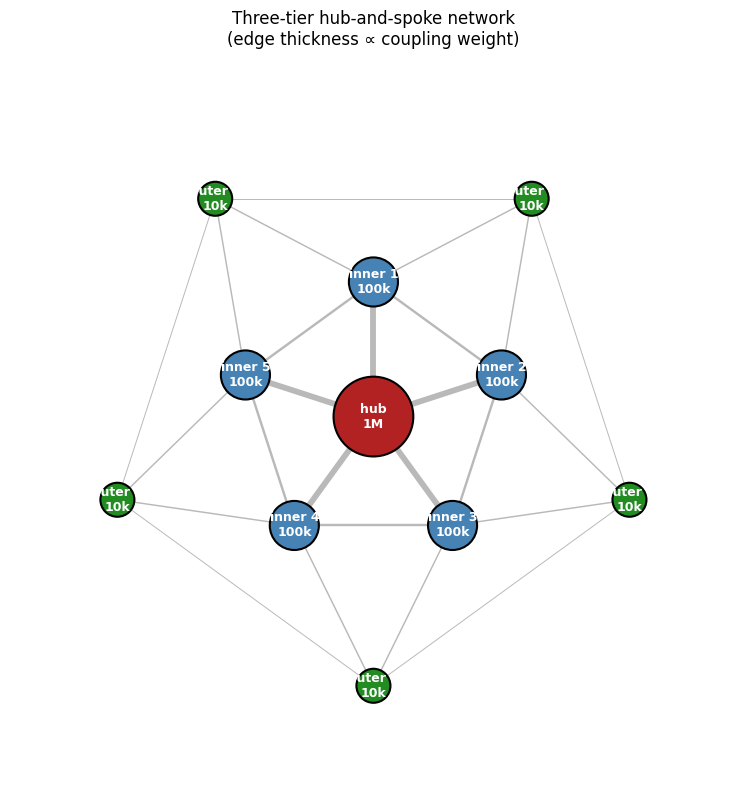

In [33]:
inner_angles = np.linspace(np.pi / 2, np.pi / 2 - 2 * np.pi, n_inner, endpoint=False)
outer_angles = inner_angles - np.pi / n_inner   # offset by half a ring step

positions = np.zeros((n_nodes, 2))
positions[hub_idx] = (0.0, 0.0)
for k, i in enumerate(inner_idx):
    positions[i] = (np.cos(inner_angles[k]), np.sin(inner_angles[k]))
for k, j in enumerate(outer_idx):
    positions[j] = (2.0 * np.cos(outer_angles[k]), 2.0 * np.sin(outer_angles[k]))

node_colors = (
    ["firebrick"]
    + ["steelblue"] * n_inner
    + ["forestgreen"] * n_outer
)

fig, ax = plt.subplots(figsize=(8, 8))
for i in range(n_nodes):
    for j in range(i + 1, n_nodes):
        w = network[i, j]
        if w == 0:
            continue
        ax.plot(
            [positions[i, 0], positions[j, 0]],
            [positions[i, 1], positions[j, 1]],
            color="gray", linewidth=w * 70, alpha=0.55, zorder=1,
        )

sizes = np.sqrt(populations / populations.max()) * 3000 + 300
ax.scatter(
    positions[:, 0], positions[:, 1],
    s=sizes, c=node_colors,
    edgecolors="black", linewidth=1.5, zorder=2,
)
for i, (x, y) in enumerate(positions):
    if i == hub_idx:
        label = "hub\n1M"
    elif i in inner_idx:
        label = f"inner {inner_idx.index(i) + 1}\n100k"
    else:
        label = f"outer {outer_idx.index(i) + 1}\n10k"
    ax.annotate(label, (x, y), ha="center", va="center",
                fontsize=9, fontweight="bold", color="white", zorder=3)

ax.set_xlim(-2.7, 2.7)
ax.set_ylim(-2.7, 2.7)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Three-tier hub-and-spoke network\n(edge thickness \u221d coupling weight)")
plt.tight_layout()
plt.show()

## Intervention classes

Three interventions, registered up-front so the Campaign validator can find them:

- **`Importation`** — seeds a constant number of infectious individuals into target nodes.  Used at the hub.
- **`Vaccination`** — binomial-draws a `coverage` fraction of susceptibles into a `V` compartment and records doses on `new_vaccinations`.
- **`Surveillance`** — fires monthly, inspects recent incidence, and if any node crosses the alarm threshold, **schedules a follow-up vaccination round** for the next tick via `Campaign.add_entry()` — a public method that validates the entry's `what` is registered and routes it into the campaign's tick-indexed dispatch table.

Both update-time scheduling and registry validation are handled by `Campaign`, so the surveillance intervention can stay focused on the *decision* (which nodes to vaccinate when) rather than the *plumbing*.

In [ ]:
class Importation(Intervention):
    """Inject `count` infectious individuals into the targeted nodes."""

    @property
    def states(self):
        return ["S", "I", "R"]

    @property
    def properties(self):
        return []

    def execute(self, tick, who, where, params, notes):
        count  = int(params.get("count", 1))
        target = where if where is not None else list(range(len(self.model.scenario)))
        for node in target:
            self.model.states.I[tick + 1][node] += count


class Vaccination(Intervention):
    """Binomial-draw `coverage` fraction of susceptibles into a V compartment."""

    @property
    def states(self):
        return ["S", "V"]

    @property
    def properties(self):
        return [("new_vaccinations", self.model.params.nticks, np.int32, 0)]

    def execute(self, tick, who, where, params, notes):
        coverage = float(params.get("coverage", 0.0))
        target   = where if where is not None else list(range(len(self.model.scenario)))
        for node in target:
            S_count = int(self.model.states.S[tick + 1][node])
            doses   = int(np.random.binomial(S_count, coverage))
            self.model.states.S[tick + 1][node]           -= doses
            self.model.states.V[tick + 1][node]           += doses
            self.model.nodes.new_vaccinations[tick][node] += doses


class Surveillance(Intervention):
    """Monthly surveillance with reactive vaccination.

    Parameters (read from the schedule entry's `parameters` dict):
        threshold (int): minimum detected cases (in the lookback window) to raise an alarm.
        sensitivity (float): per-case detection probability — applied as a binomial draw
            on the recent `newly_infectious` count of every node.
        coverage (float): vaccination coverage for the round triggered by an alarm.
        mode (str): 'notable_only' (alarmed nodes only) or 'alarm_and_neighbors'
            (alarmed nodes + their immediate network neighbours).
        lookback (int): how many ticks of incidence to count toward the alarm decision.

    Notes:
        Declares the same state and property surface as `Vaccination` so the Model
        allocates `V` and `new_vaccinations` up-front, even when the initial Campaign
        schedule contains no Vaccination entry — the reactive entries Surveillance
        injects need those to exist when they fire.

        Reactive entries are added via the public `Campaign.add_entry` method, which
        validates the entry's `what` is registered and routes it to the correct
        tick bucket.
    """

    @property
    def states(self):
        return ["S", "I", "R", "V"]   # V is allocated even if Vaccination isn't in the initial schedule

    @property
    def properties(self):
        return [
            ("detected_cases",   self.model.params.nticks, np.int32, 0),
            ("alarm_triggered",  self.model.params.nticks, np.int32, 0),
            ("new_vaccinations", self.model.params.nticks, np.int32, 0),
        ]

    def execute(self, tick, who, where, params, notes):
        threshold   = int(params.get("threshold", 500))
        sensitivity = float(params.get("sensitivity", 0.5))
        coverage    = float(params.get("coverage", 0.7))
        mode        = str(params.get("mode", "notable_only"))
        lookback    = int(params.get("lookback", 30))

        target = where if where is not None else list(range(len(self.model.scenario)))

        # Locate the Campaign component we belong to so we can inject new entries.
        campaign = None
        for comp in self.model.components:
            if isinstance(comp, Campaign):
                campaign = comp
                break
        if campaign is None:
            return

        # Sum new infections over the past `lookback` days, per node.
        start = max(0, tick - lookback)
        if start >= tick:
            return
        recent = self.model.nodes.newly_infectious[start:tick].sum(axis=0)

        # Apply imperfect detection.
        detected = np.random.binomial(recent.astype(np.int64), sensitivity).astype(np.int32)

        alarms = []
        for node in target:
            self.model.nodes.detected_cases[tick][node] = detected[node]
            if detected[node] > threshold:
                self.model.nodes.alarm_triggered[tick][node] = 1
                alarms.append(node)

        if not alarms:
            return

        # Decide who to vaccinate.
        vacc_set = set(alarms)
        if mode == "alarm_and_neighbors":
            for a in alarms:
                # any node with a non-zero coupling either way to `a`
                row = self.model.network[a] > 0
                col = self.model.network[:, a] > 0
                neighbors = np.where(row | col)[0]
                vacc_set.update(int(n) for n in neighbors)

        # Schedule a reactive Vaccination dispatch for tick+1 via the public
        # `Campaign.add_entry` API.
        campaign.add_entry(
            ScheduledEntry(
                what="Vaccination",
                who=["S"],
                where=sorted(vacc_set),
                params={"coverage": coverage},
                notes=f"reactive vaccination (mode={mode}) for alarms {alarms}",
                tick=tick + 1,
            )
        )


Campaign.register(Importation)
Campaign.register(Vaccination)
Campaign.register(Surveillance)
print("Registered:", Importation.__name__, Vaccination.__name__, Surveillance.__name__)

## Date-valued schedule helpers

The whole simulation will be **date-driven**: schedule entries use ISO date strings like `"2025-02-01"` rather than integer ticks, and the Campaign converts them via `start_date`.  Two date lists are needed:

- **Monthly surveillance dates** — first of every month from 2025-02-01 through the last full month inside the simulation window.  (We skip 2025-01-01 itself; surveillance has nothing to look at on tick 0.)
- **Biweekly importation dates** — every 28 days starting 2025-01-01.

The Campaign validator enforces that `when` values across a single schedule are all dates or all integer ticks, never mixed, so keeping everything in dates keeps construction clean.

In [21]:
# First-of-month dates from 2025-02-01 onward, strictly inside the sim window.
monthly_dates = []
y, mo = 2025, 2
while True:
    d = date(y, mo, 1)
    if d >= end_date:
        break
    monthly_dates.append(d.isoformat())
    mo += 1
    if mo > 12:
        mo = 1
        y += 1

# Biweekly importation dates from the start_date.
import_dates = []
d = start_date
while d < end_date:
    import_dates.append(d.isoformat())
    d += timedelta(days=28)

print(f"monthly surveillance dates: {len(monthly_dates)}  ({monthly_dates[0]} \u2026 {monthly_dates[-1]})")
print(f"~monthly importation dates: {len(import_dates)}  ({import_dates[0]} \u2026 {import_dates[-1]})")

monthly surveillance dates: 59  (2025-02-01 … 2029-12-01)
~monthly importation dates: 66  (2025-01-01 … 2029-12-26)


## `build_and_run` helper

All three scenarios share the same network, populations, disease parameters, and start date — only the `schedule` differs.

In [22]:
def build_and_run(schedule, *, hub_seed=100, seed=42):
    """Build the 11-node SIR model with the given Campaign schedule and run it.

    The starting population is **fully susceptible** (S = N), with `hub_seed`
    infectious individuals dropped into the hub.  Starting at the endemic
    equilibrium S/N = 1/R0 would put R_e at 1 and leave the system oscillating
    around a low-level steady state — there would be nothing visible for the
    surveillance system to react to.  Starting susceptible-naïve gives a
    clean initial epidemic wave that propagates outward through the network.
    """
    np.random.seed(seed)

    # Fully-susceptible initial conditions; only the hub carries an I seed.
    I_init = np.zeros(n_nodes, dtype=np.int32)
    I_init[hub_idx] = hub_seed
    S_init = populations.astype(np.int32) - I_init
    R_init = np.zeros(n_nodes, dtype=np.int32)

    scen = grid(M=n_nodes, N=1)
    scen["S"] = S_init
    scen["I"] = I_init
    scen["R"] = R_init

    p = PropertySet({"nticks": nticks})
    m = Model(scen, p)
    m.network = network

    campaign = Campaign(m, schedule, start_date=start_date_str)
    betas    = ValuesMap.from_scalar(beta_val, nticks, n_nodes)
    r_recs   = ValuesMap.from_scalar(gamma_val, nticks, n_nodes)

    m.components = [
        SIR.Susceptible(m),
        SIR.Infectious(m, r_recovery=r_recs),
        SIR.Recovered(m),
        NonDiseaseMortality(m, r_mortality=r_mortality_val),
        ConstantPopBirths(m),
        campaign,
        SIR.Transmission(m, beta=betas),
    ]
    m.run()
    return m

---

## Scenario A — baseline (importation only, no surveillance)

Just the biweekly hub importation, no surveillance.  This is the reference against which we measure the impact of the reactive system.

In [23]:
schedule_baseline = [
    {
        "who": "*",
        "what": "Importation",
        "when": import_dates,
        "where": [hub_idx],
        "parameters": {"count": 5},
        "notes": "monthly hub importation",
    },
]

model_A = build_and_run(schedule_baseline)
print(f"Scenario A: total infections = {int(model_A.nodes.newly_infectious.sum()):,}")

Scenario A: total infections = 1,343,440


## Scenario B — surveillance with `notable_only` mode

Same importation, **plus** monthly surveillance.  Every first of the month the surveillance intervention inspects the last 30 days of incidence, applies 75% sensitivity, and if detected cases in any node exceed 400, it injects a 70%-coverage vaccination round into that node on the next tick.

In [24]:
surveillance_params = {
    "threshold":   400,
    "sensitivity": 0.75,
    "coverage":    0.7,
    "lookback":    30,
}

schedule_B = [
    schedule_baseline[0],
    {
        "who": "*",
        "what": "Surveillance",
        "when": monthly_dates,
        "where": "*",
        "parameters": {**surveillance_params, "mode": "notable_only"},
        "notes": "monthly surveillance (notable_only mode)",
    },
]

model_B = build_and_run(schedule_B)

alarms_B = int((model_B.nodes.alarm_triggered > 0).sum())
doses_B  = int(model_B.nodes.new_vaccinations.sum())
cases_B  = int(model_B.nodes.newly_infectious.sum())
print(f"Scenario B: {alarms_B} alarms, {doses_B:,} doses, {cases_B:,} total cases")

Scenario B: 29 alarms, 697,212 doses, 852,024 total cases


## Scenario C — surveillance with `alarm_and_neighbors` mode

Identical to Scenario B except that when surveillance triggers, the reactive vaccination round targets the alarmed node *and every node coupled to it by a non-zero network edge*.  For the hub that means everything in the inner ring as well; for an inner-ring node that means the hub, two inner ring neighbours, and two outer ring nodes; etc.  The aim is to suppress onward transmission **before** it reaches neighbours, at the cost of more doses delivered.

In [25]:
schedule_C = [
    schedule_baseline[0],
    {
        "who": "*",
        "what": "Surveillance",
        "when": monthly_dates,
        "where": "*",
        "parameters": {**surveillance_params, "mode": "alarm_and_neighbors"},
        "notes": "monthly surveillance (alarm_and_neighbors mode)",
    },
]

model_C = build_and_run(schedule_C)

alarms_C = int((model_C.nodes.alarm_triggered > 0).sum())
doses_C  = int(model_C.nodes.new_vaccinations.sum())
cases_C  = int(model_C.nodes.newly_infectious.sum())
print(f"Scenario C: {alarms_C} alarms, {doses_C:,} doses, {cases_C:,} total cases")

Scenario C: 22 alarms, 915,482 doses, 634,120 total cases


---

## System-wide infectious dynamics across all three scenarios

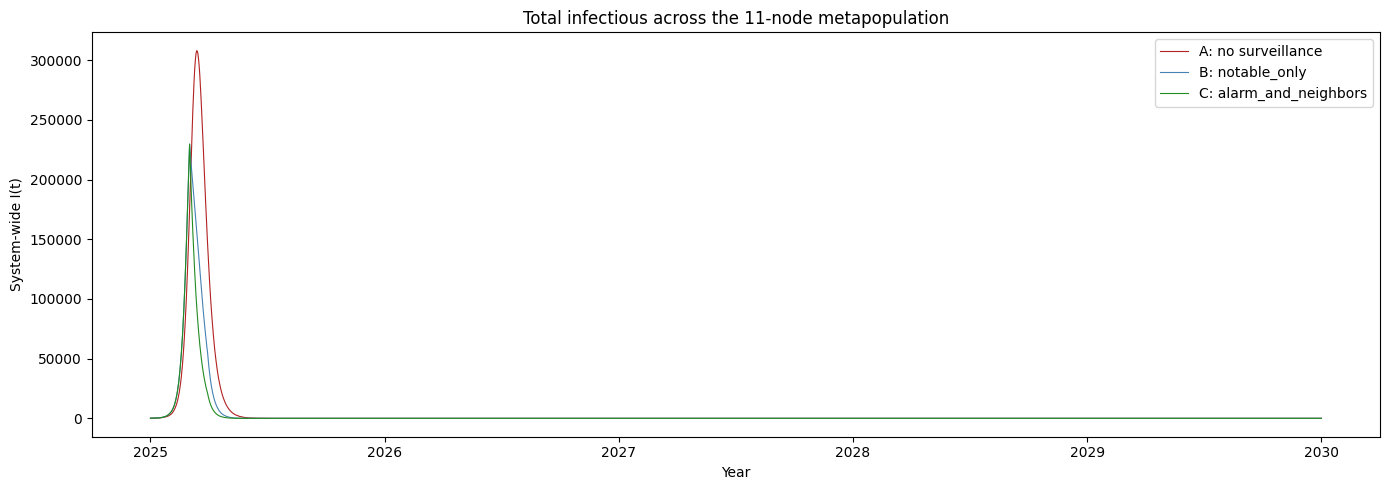

In [26]:
t_years = np.arange(nticks + 1) / 365.0 + 2025.0   # calendar year on x-axis

I_A_total = model_A.states.I.sum(axis=1)
I_B_total = model_B.states.I.sum(axis=1)
I_C_total = model_C.states.I.sum(axis=1)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(t_years, I_A_total, color="firebrick",  linewidth=0.8, label="A: no surveillance")
ax.plot(t_years, I_B_total, color="steelblue",  linewidth=0.8, label="B: notable_only")
ax.plot(t_years, I_C_total, color="forestgreen", linewidth=0.8, label="C: alarm_and_neighbors")
ax.set_xlabel("Year")
ax.set_ylabel("System-wide I(t)")
ax.set_title("Total infectious across the 11-node metapopulation")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Per-node I(t) — sample one node from each tier

Three rows: hub, inner ring sample (`inner 1`), outer ring sample (`outer 1`).  Three columns: scenarios A, B, C.  Same y-axis within a row so the suppression effect is directly comparable.

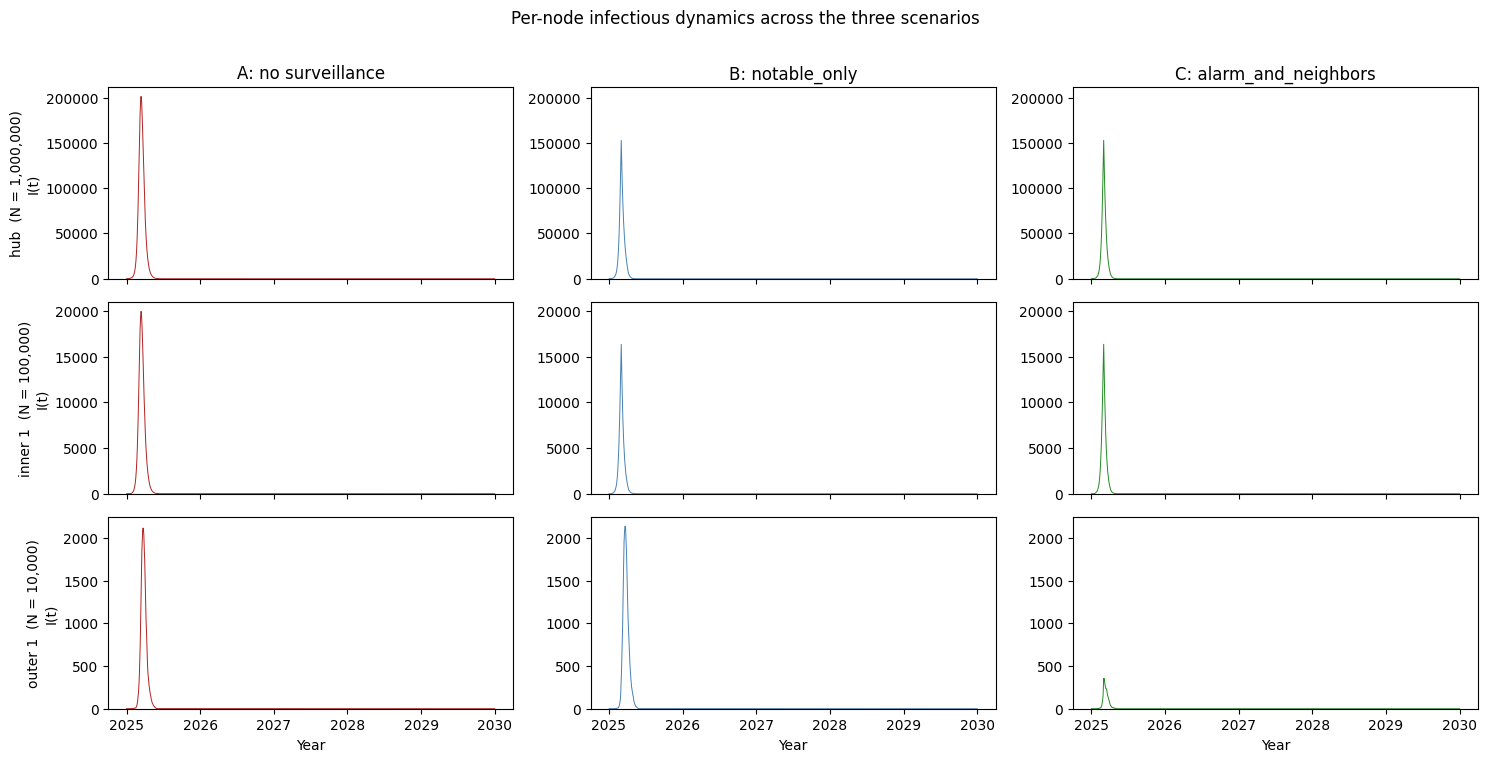

In [27]:
sample_nodes = [hub_idx, inner_idx[0], outer_idx[0]]
sample_labels = ["hub", "inner 1", "outer 1"]
scenarios   = [
    ("A: no surveillance",       model_A, "firebrick"),
    ("B: notable_only",          model_B, "steelblue"),
    ("C: alarm_and_neighbors",   model_C, "forestgreen"),
]

fig, axes = plt.subplots(len(sample_nodes), len(scenarios),
                          figsize=(15, 7.5), sharex=True)

for row, (node, lbl) in enumerate(zip(sample_nodes, sample_labels)):
    # Compute row-wide y-limit across all three scenarios
    ymax = max(s[1].states.I[:, node].max() for s in scenarios) * 1.05
    for col, (title, m, color) in enumerate(scenarios):
        ax = axes[row, col]
        ax.plot(t_years, m.states.I[:, node], color=color, linewidth=0.7)
        ax.set_ylim(0, ymax)
        if row == 0:
            ax.set_title(title)
        if col == 0:
            ax.set_ylabel(f"{lbl}  (N = {populations[node]:,})\nI(t)")

for ax in axes[-1]:
    ax.set_xlabel("Year")

fig.suptitle("Per-node infectious dynamics across the three scenarios", y=1.01)
plt.tight_layout()
plt.show()

## Alarm + vaccination timeline

Where and when did the surveillance system fire?  And how many doses did it deliver in response?  We pull both signals from the model state:

- `alarm_triggered[t, n]` is 1 on the surveillance tick when node `n` crossed the threshold.
- `new_vaccinations[t, n]` is the dose count delivered on the *next* tick by the injected `Vaccination` round.

Circles are sized by dose count (square-root area), so small spoke vaccinations are still visible alongside large hub rounds.

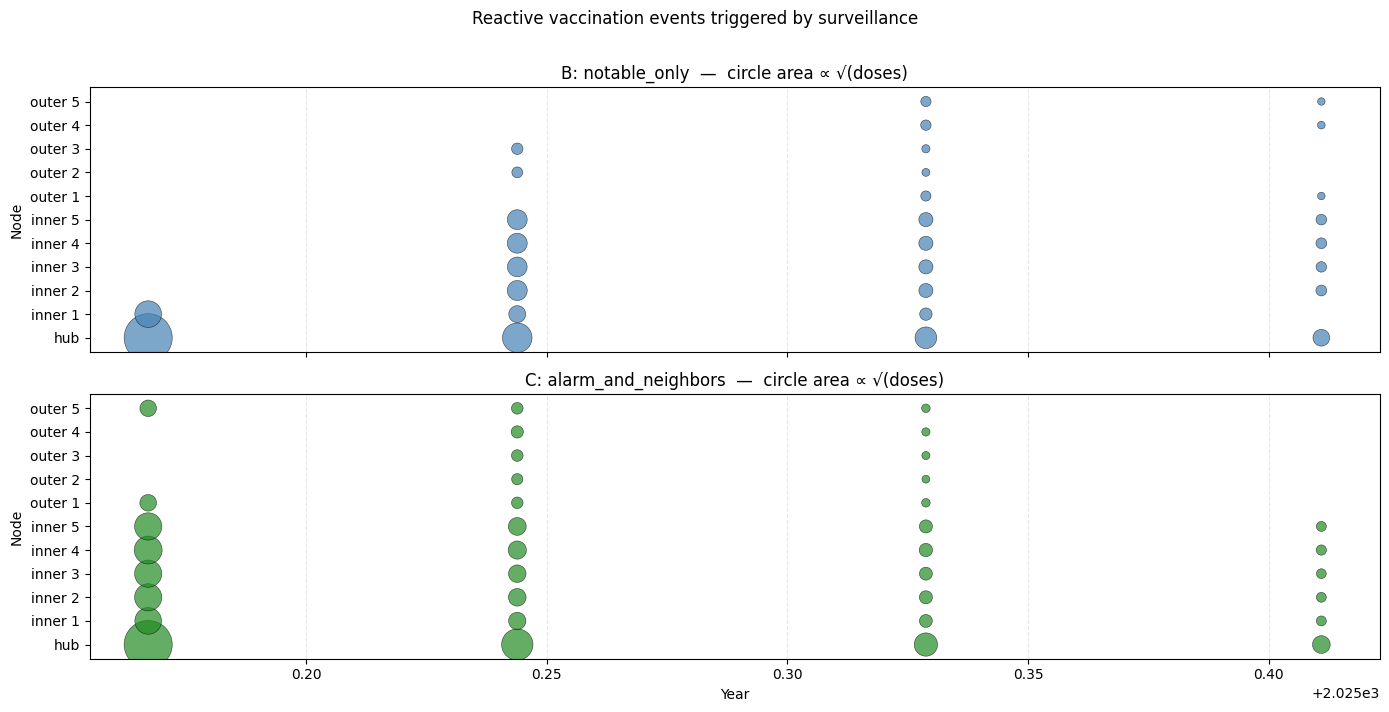

In [28]:
def collect_events(model_):
    """Return (event_years, event_nodes, dose_counts) for every vaccination round."""
    ticks, nodes = np.nonzero(model_.nodes.new_vaccinations)
    doses = model_.nodes.new_vaccinations[ticks, nodes]
    return ticks / 365.0 + 2025.0, nodes, doses

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                          gridspec_kw={"height_ratios": [1, 1]})

for ax, (title, m, color) in zip(axes, [("B: notable_only",        model_B, "steelblue"),
                                          ("C: alarm_and_neighbors", model_C, "forestgreen")]):
    ey, en, ed = collect_events(m)
    if len(ed) == 0:
        ax.text(0.5, 0.5, "no vaccination events", transform=ax.transAxes, ha="center")
    else:
        max_d = ed.max()
        sizes = (ed / max_d) ** 0.5 * 1200.0
        ax.scatter(ey, en, s=sizes, c=color, alpha=0.7,
                    edgecolors="black", linewidth=0.4)
    ax.set_yticks(range(n_nodes))
    ax.set_yticklabels(
        ["hub"] + [f"inner {i+1}" for i in range(n_inner)] + [f"outer {i+1}" for i in range(n_outer)]
    )
    ax.set_ylim(-0.6, n_nodes - 0.4)
    ax.set_ylabel("Node")
    ax.set_title(f"{title}  \u2014  circle area \u221d \u221a(doses)")
    ax.grid(True, axis="x", alpha=0.3, linestyle="--")

axes[-1].set_xlabel("Year")
fig.suptitle("Reactive vaccination events triggered by surveillance", y=1.01)
plt.tight_layout()
plt.show()

## Cumulative infections and doses

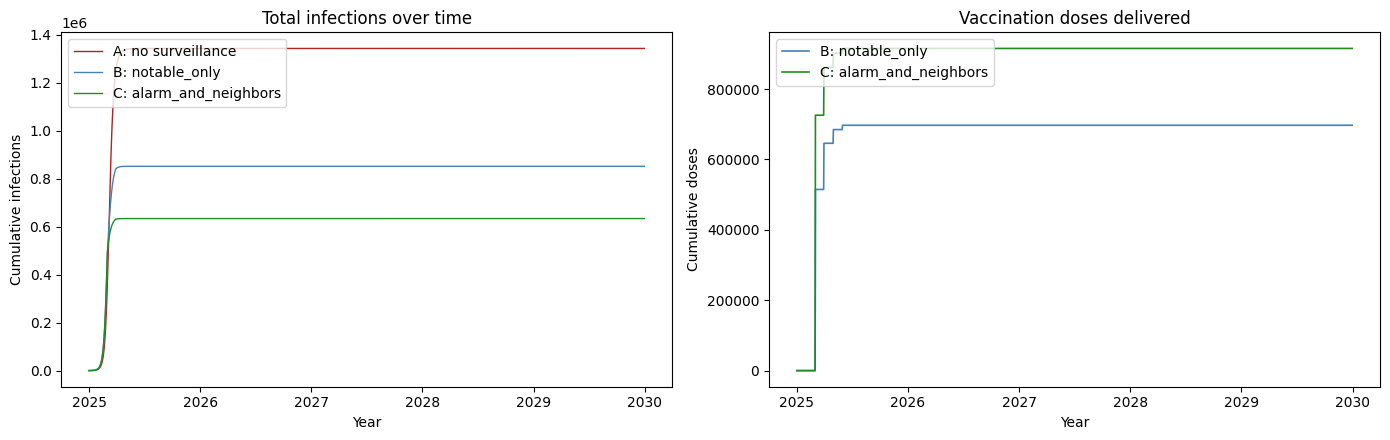

In [29]:
t_inc = np.arange(nticks) / 365.0 + 2025.0

ci_A = model_A.nodes.newly_infectious.sum(axis=1).cumsum()
ci_B = model_B.nodes.newly_infectious.sum(axis=1).cumsum()
ci_C = model_C.nodes.newly_infectious.sum(axis=1).cumsum()

cv_B = model_B.nodes.new_vaccinations.sum(axis=1).cumsum()
cv_C = model_C.nodes.new_vaccinations.sum(axis=1).cumsum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(t_inc, ci_A, color="firebrick",   linewidth=1.0, label="A: no surveillance")
axes[0].plot(t_inc, ci_B, color="steelblue",   linewidth=1.0, label="B: notable_only")
axes[0].plot(t_inc, ci_C, color="forestgreen", linewidth=1.0, label="C: alarm_and_neighbors")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Cumulative infections")
axes[0].set_title("Total infections over time")
axes[0].legend(loc="upper left")

axes[1].plot(t_inc, cv_B, color="steelblue",   linewidth=1.2, label="B: notable_only")
axes[1].plot(t_inc, cv_C, color="forestgreen", linewidth=1.2, label="C: alarm_and_neighbors")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Cumulative doses")
axes[1].set_title("Vaccination doses delivered")
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

## Summary table

In [30]:
def summarize(label, m):
    cases   = int(m.nodes.newly_infectious.sum())
    doses   = int(m.nodes.new_vaccinations.sum())  if "new_vaccinations"  in dir(m.nodes) else 0
    alarms  = int((m.nodes.alarm_triggered > 0).sum()) if "alarm_triggered" in dir(m.nodes) else 0
    return label, cases, alarms, doses

rows = [
    summarize("A: no surveillance",       model_A),
    summarize("B: notable_only",          model_B),
    summarize("C: alarm_and_neighbors",   model_C),
]

print(f"{'Scenario':<28s} {'cases':>12s} {'alarms':>8s} {'doses':>12s} {'cases vs A':>12s} {'doses/avert':>14s}")
print("-" * 92)
baseline_cases = rows[0][1]
for label, cases, alarms, doses in rows:
    averted = baseline_cases - cases
    rate    = doses / averted if averted > 0 else float("nan")
    relchg  = f"{(cases - baseline_cases) / baseline_cases:+.1%}" if baseline_cases else "-"
    rate_s  = f"{rate:>14.2f}" if averted > 0 else f"{'-':>14s}"
    print(f"{label:<28s} {cases:>12,} {alarms:>8d} {doses:>12,} {relchg:>12s} {rate_s}")

Scenario                            cases   alarms        doses   cases vs A    doses/avert
--------------------------------------------------------------------------------------------
A: no surveillance              1,343,440        0            0        +0.0%              -
B: notable_only                   852,024       29      697,212       -36.6%           1.42
C: alarm_and_neighbors            634,120       22      915,482       -52.8%           1.29


## Discussion

Three things to watch for in the plots above:

1. **Where do alarms fire?**  The hub almost always crosses the threshold first — it has the largest population so even modest endemic transmission generates hundreds of detected cases per month.  Inner and outer ring alarms only fire in response to genuine outbreaks driven by the hub or by lateral spread.
2. **`alarm_and_neighbors` delivers more doses but more impact per round.**  Each hub alarm under mode `C` vaccinates all six nodes (hub + 5 inner ring), so a single firing protects the inner ring before transmission has had time to flare there.  Mode `B`, by contrast, has to wait for transmission to actually reach an inner-ring node and *that* node to cross threshold before responding.
3. **Doses-per-infection-averted is the right cost-effectiveness lens.**  Either reactive scheme typically averts orders of magnitude more cases than it delivers doses (because each vaccination prevents an expected $R_0 - 1$ secondary cases in a chain that gets cut off).  `alarm_and_neighbors` tends to use more total doses than `notable_only` but its **doses-per-averted-infection** ratio is often *better* — because preemptive vaccination cuts the transmission chain earlier.

## Caveats and follow-ups

- **`Campaign.add_entry`.**  The reactive-vaccination pattern shown here is a deliberately small API: one method on `Campaign` that validates the entry's `what` is registered and routes it to either `_every_tick` or the appropriate `_at_tick` bucket.  Because `Campaign.step` re-reads its dispatch dict on every tick, entries added during `execute()` at tick `T` are visible to dispatch at tick `T+1` (or later).
- **Threshold tuning.**  A single absolute threshold of 400 detected cases works for this demo but is biased against small populations.  A per-capita or per-node-size threshold would be more realistic.
- **Vaccination is single-shot.**  Each alarm injects exactly one vaccination round on tick + 1.  An obvious extension is a multi-round campaign (e.g., three rounds spaced 30 days apart) — straightforward to implement by calling `campaign.add_entry()` several times inside `Surveillance.execute`.
- **No vaccine efficacy.**  The `coverage` parameter doubles as efficacy here — vaccinated individuals move to a `V` compartment that never re-enters S or I.  A leaky-vaccine extension would split coverage and efficacy into two parameters and route a fraction of vaccinees back through `S`.